# Prac 03. Part 2



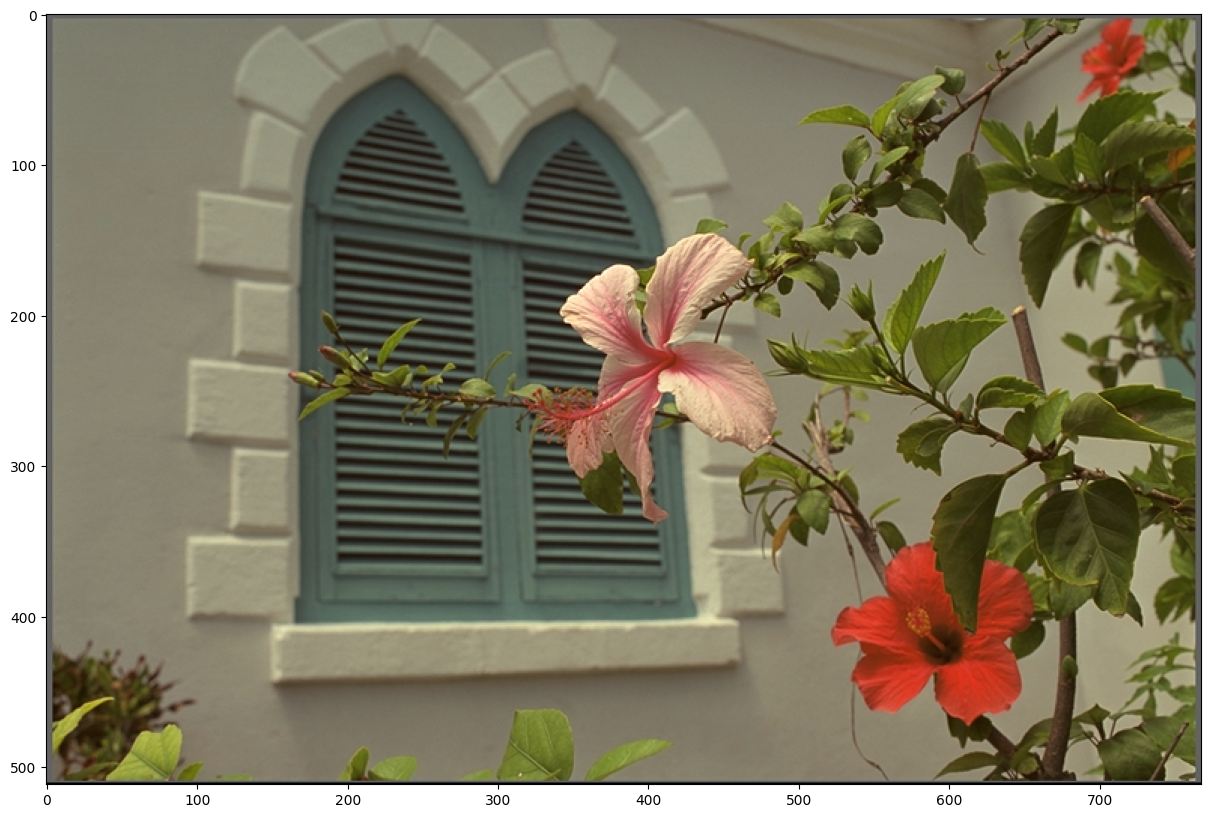

In [12]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [18, 10]

img = cv2.imread('/content/kodim07.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(img)

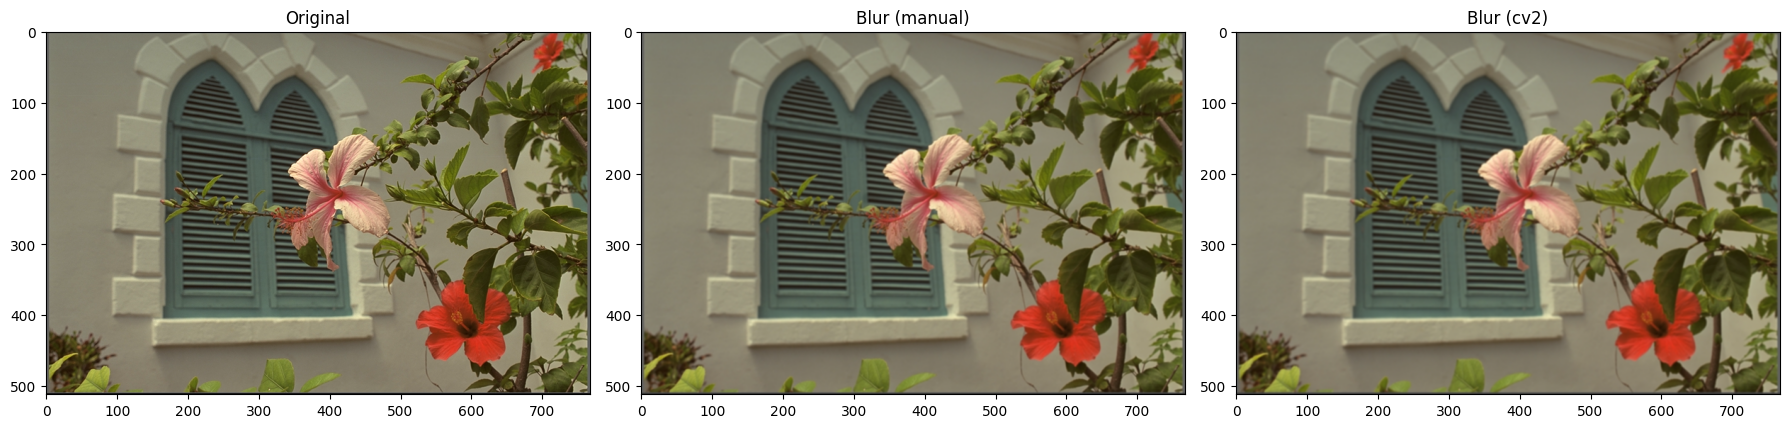

In [13]:
kernel_blur = np.array([
    [0.000789, 0.006581, 0.013347, 0.006581, 0.000789],
    [0.006581, 0.054901, 0.111345, 0.054901, 0.006581],
    [0.013347, 0.111345, 0.225821, 0.111345, 0.013347],
    [0.006581, 0.054901, 0.111345, 0.054901, 0.006581],
    [0.000789, 0.006581, 0.013347, 0.006581, 0.000789]
])
blur_manual = cv2.filter2D(img, -1, kernel_blur)

blur_cv2 = cv2.GaussianBlur(img, (5, 5), 0)

plt.subplot(131), plt.imshow(img), plt.title('Original')
plt.subplot(132), plt.imshow(blur_manual), plt.title('Blur (manual)')
plt.subplot(133), plt.imshow(blur_cv2), plt.title('Blur (cv2)')
plt.tight_layout()
plt.show()

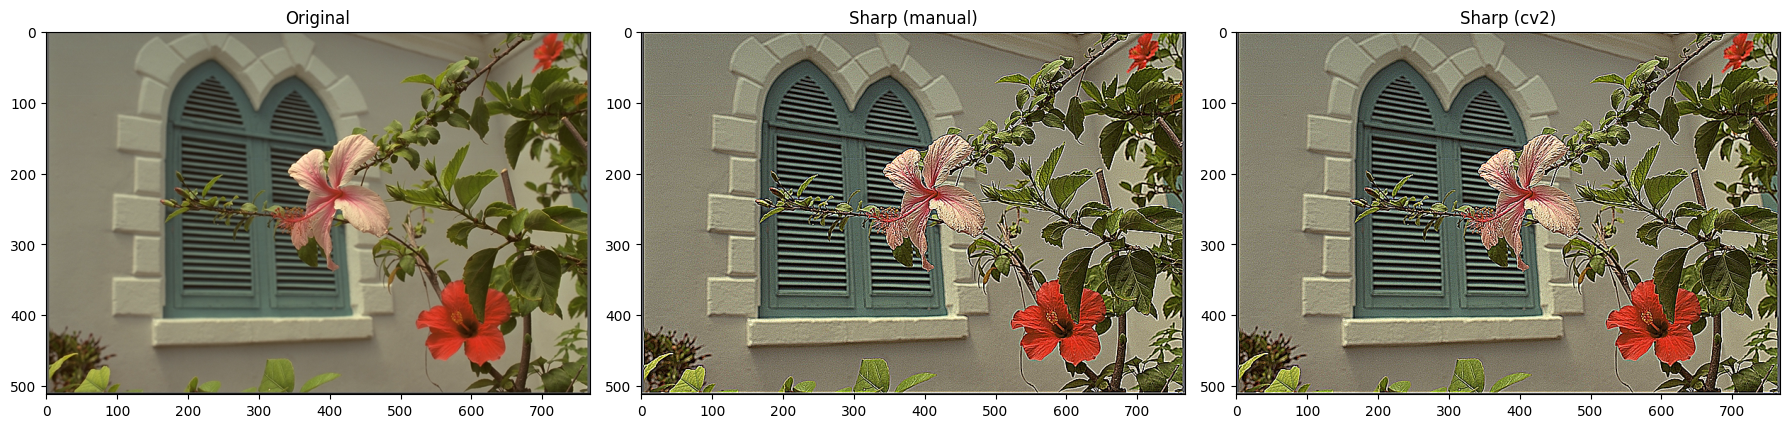

In [15]:

kernel_sharp = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
])
sharp_manual = cv2.filter2D(img, -1, kernel_sharp)
sharp_cv2 = cv2.filter2D(img, -1, kernel_sharp)

plt.subplot(131), plt.imshow(img), plt.title('Original')
plt.subplot(132), plt.imshow(sharp_manual), plt.title('Sharp (manual)')
plt.subplot(133), plt.imshow(sharp_cv2), plt.title('Sharp (cv2)')
plt.tight_layout()
plt.show()

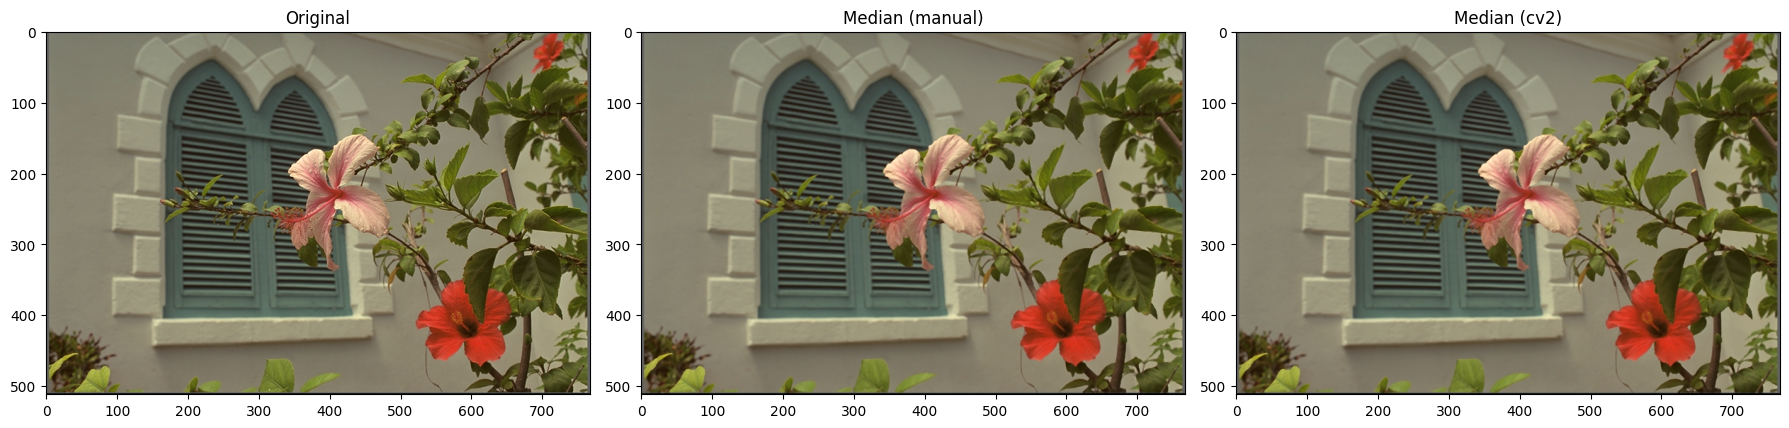

In [17]:

def median_filter_manual(image, ksize=3):
    pad = ksize // 2
    result = np.zeros_like(image)
    padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            for c in range(3):
                region = padded[i:i+ksize, j:j+ksize, c]
                result[i, j, c] = np.median(region)
    return result

median_manual = median_filter_manual(img, ksize=3)
median_cv2 = cv2.medianBlur(img, 3)

plt.subplot(131), plt.imshow(img), plt.title('Original')
plt.subplot(132), plt.imshow(median_manual), plt.title('Median (manual)')
plt.subplot(133), plt.imshow(median_cv2), plt.title('Median (cv2)')
plt.tight_layout()
plt.show()

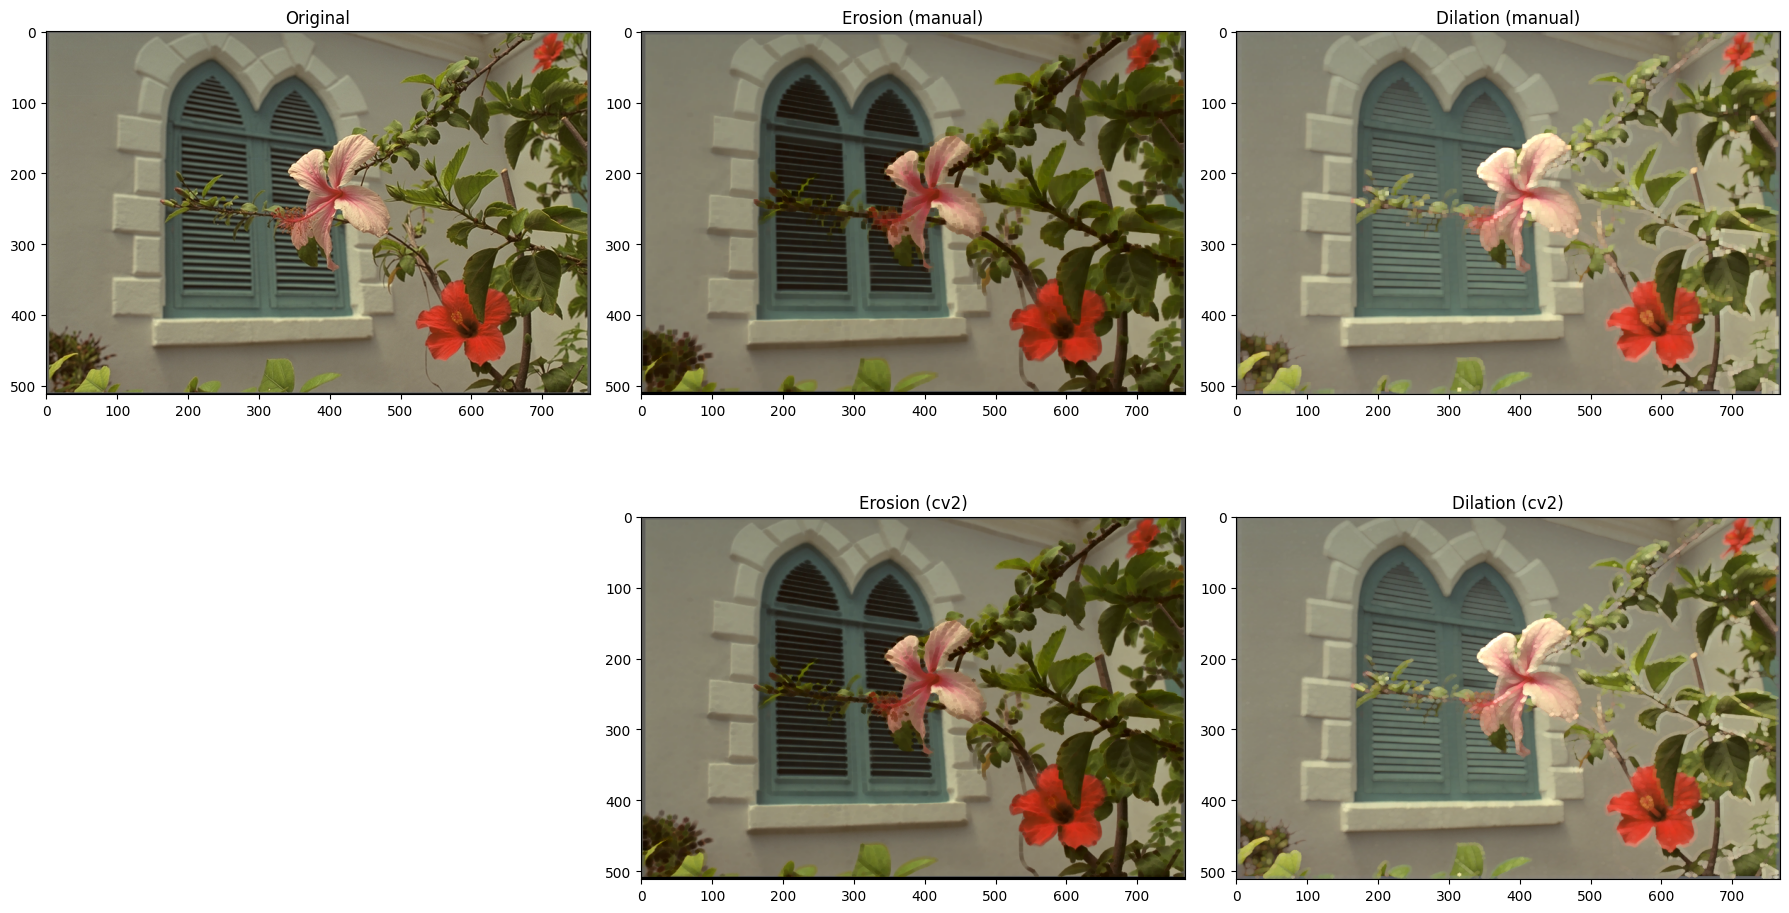

In [18]:

def erosion_manual(image, ksize=5):
    pad = ksize // 2
    result = np.zeros_like(image)
    padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            for c in range(3):
                region = padded[i:i+ksize, j:j+ksize, c]
                result[i, j, c] = np.min(region)
    return result

def dilation_manual(image, ksize=5):
    pad = ksize // 2
    result = np.zeros_like(image)
    padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            for c in range(3):
                region = padded[i:i+ksize, j:j+ksize, c]
                result[i, j, c] = np.max(region)
    return result

erosion_man = erosion_manual(img, ksize=5)
dilation_man = dilation_manual(img, ksize=5)


kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
erosion_cv2 = cv2.erode(img, kernel_morph)
dilation_cv2 = cv2.dilate(img, kernel_morph)

plt.subplot(231), plt.imshow(img), plt.title('Original')
plt.subplot(232), plt.imshow(erosion_man), plt.title('Erosion (manual)')
plt.subplot(233), plt.imshow(dilation_man), plt.title('Dilation (manual)')
plt.subplot(235), plt.imshow(erosion_cv2), plt.title('Erosion (cv2)')
plt.subplot(236), plt.imshow(dilation_cv2), plt.title('Dilation (cv2)')
plt.tight_layout()
plt.show()

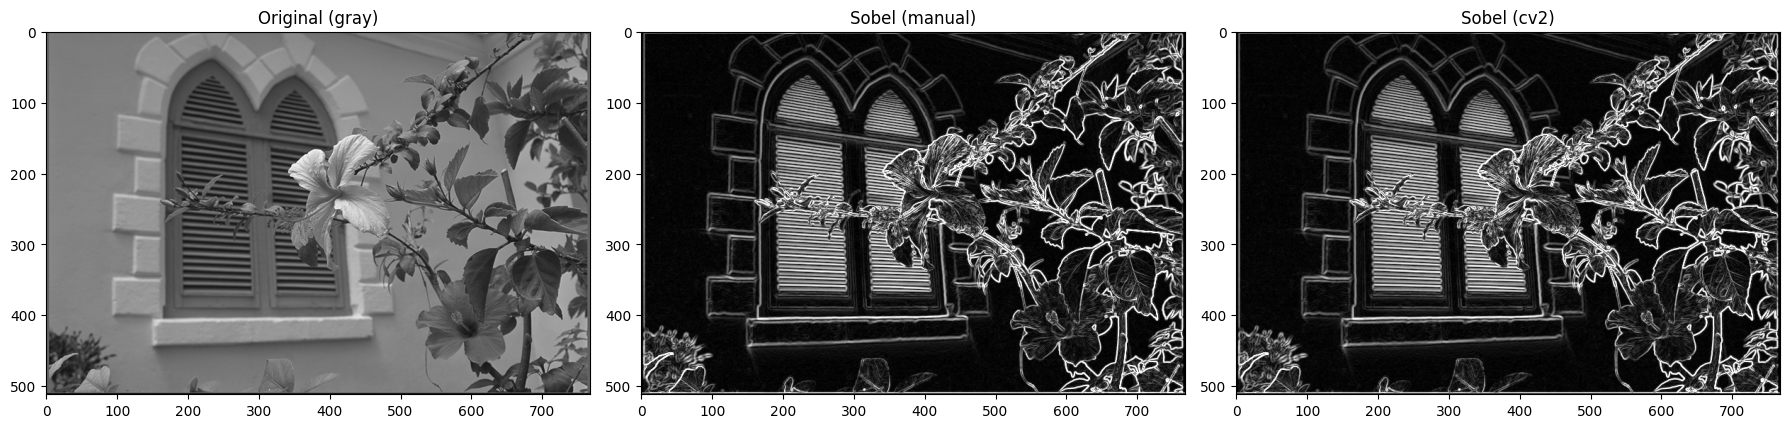

In [19]:

kernel_sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

kernel_sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

Gx = cv2.filter2D(img_gray.astype(np.float32), -1, kernel_sobel_x)
Gy = cv2.filter2D(img_gray.astype(np.float32), -1, kernel_sobel_y)
sobel_manual = np.sqrt(Gx**2 + Gy**2)
sobel_manual = np.clip(sobel_manual, 0, 255).astype(np.uint8)


sobel_x_cv2 = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_cv2 = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_cv2 = np.sqrt(sobel_x_cv2**2 + sobel_y_cv2**2)
sobel_cv2 = np.clip(sobel_cv2, 0, 255).astype(np.uint8)

plt.subplot(131), plt.imshow(img_gray, cmap='gray'), plt.title('Original (gray)')
plt.subplot(132), plt.imshow(sobel_manual, cmap='gray'), plt.title('Sobel (manual)')
plt.subplot(133), plt.imshow(sobel_cv2, cmap='gray'), plt.title('Sobel (cv2)')
plt.tight_layout()
plt.show()